# __Data Visualization__

## __WHT Data__

### __1. Data preprocessing__

In [1]:
import glob, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

# Training files
files = glob.glob('../data/WHT_data/WHT_weather_set_parts_*')
files = sorted(files)
WHT_parts = [pd.read_csv(file_path) for file_path in files]

# Concatenate the DataFrames into a single training set
WHT_data = pd.concat(WHT_parts, ignore_index=True)

/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/tmp/ipykernel_40891/3604653322.py:6: DtypeWarning: Columns (1,3) have mixed types. Specify dtype option on import or set low_memory=False.
  WHT_parts = [pd.read_csv(file_path) for file_path in files]
/tmp/ipykernel_40891/3604653322.py:6: DtypeWarning: Columns (2,3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  WHT_parts = [pd.read_csv(file_path) for file_path in files]
/tmp/ipykernel_40891/3604653322.py:6: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  WHT_parts = [pd.read_csv(file_path) for file_path in files]
/tmp/ipykernel_40891/3604653322.py:6: DtypeWarning: Columns (1,2,3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  WHT_pa

In [2]:
WHT_data['sampletime'] = pd.to_datetime(WHT_data['sampletime'])

# Extract year
WHT_data['year'] = WHT_data['sampletime'].dt.year

# Extract month
WHT_data['month'] = WHT_data['sampletime'].dt.month

# Extract day
WHT_data['day'] = WHT_data['sampletime'].dt.day

# Extract hour
WHT_data['hour'] = WHT_data['sampletime'].dt.hour

# Extract minute
WHT_data['minute'] = WHT_data['sampletime'].dt.minute

# Drop the 'sampletime' column
WHT_data.drop(columns=['sampletime'], inplace=True)

# Constraining to data from 2023
#WHT_data = WHT_data[WHT_data.year >= 2023]

WHT_data.head()

,windspeed,airtemperature,relativehumidity,localwetness,localbattery,winddirection,airpressure,dewpoint,year,month,day,hour,minute
0,7.1742,9.3159,32.342,-0.025,11.995,NaN,NaN,NaN,2020,1,31,16,59
1,6.7829,9.322,32.324,-0.025,11.994,NaN,NaN,NaN,2020,1,31,16,59
2,7.0003,9.3159,32.36,-0.025,11.995,NaN,NaN,NaN,2020,1,31,16,59
3,7.2612,9.3159,32.434,-0.025,11.994,NaN,NaN,NaN,2020,1,31,16,59
4,6.9134,9.3159,32.489,-0.025,11.994,NaN,NaN,NaN,2020,1,31,16,59


In [3]:
# Convert the numeric values into float32
# We need to convert each category into float32
columns = WHT_data.columns

# There are some missing values with '\\N' in the variables. Let's transform into an arbitrary number
for ii in columns[1:]:
    WHT_data[ii][WHT_data[ii] == '\\N'] = -1
    # Converting into float32
    WHT_data[ii] = WHT_data[ii].astype('float32')

# Converting wind speed to numeric
WHT_data['windspeed'] = pd.to_numeric(WHT_data['windspeed'], errors='coerce')

# Now we can count the number of NaNs in each category
print(WHT_data.isna().sum())

/tmp/ipykernel_40891/3806321149.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  WHT_data[ii][WHT_data[ii] == '\\N'] = -1
/tmp/ipykernel_40891/3806321149.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

windspeed             15145
airtemperature            0
relativehumidity          0
localwetness        6334884
localbattery        6334884
winddirection       5557582
airpressure         5557582
dewpoint            5557582
year                      0
month                     0
day                       0
hour                      0
minute                    0
dtype: int64


In [4]:
# Deleting the columns with more than 30% of NaNs

dim = len(WHT_data) # Dimension of the DataFrame

for ii in columns:
    nans = WHT_data[ii].isna().sum()*100/dim
    # Applying the condition over the column
    if nans > 30:
        WHT_data.drop(ii, axis=1, inplace=True)

# Deleting the remaining NaNs
WHT_data.dropna(inplace = True)

# Last, we display the type of each column
print(WHT_data.dtypes)

windspeed           float64
airtemperature      float32
relativehumidity    float32
year                float32
month               float32
day                 float32
hour                float32
minute              float32
dtype: object


### __2. Resampling the data__

In [5]:
# Converting the types of time units into integers
# We dummify the year, day, month and hour so first we need to convert the variables into integers
cols_to_int = ['hour', 'day', 'month', 'year', 'minute']
WHT_data[cols_to_int] = WHT_data[cols_to_int].astype('int32')

In [6]:
# Reseting the index of the DataFrame and droping the column Index
WHT_data.reset_index(inplace=True); WHT_data.drop('index', axis=1, inplace=True)

In [7]:
# In order to make the data coincide with the seeing, we require to resample our data. For simplicity, we
# resample each 10 minutes. First, we need a new column to resample which will be 'datetime'
WHT_data['Datetime'] = pd.to_datetime(WHT_data[['year', 'month', 'day', 'hour', 'minute']])

# Converting the Datetime column into datetime format
WHT_data.Datetime = pd.to_datetime(WHT_data['Datetime'])

# Deleting the old columns
WHT_data.drop(['year','month','day','hour','minute'], axis=1, inplace=True)

# Displaying how the data looks like
WHT_data.head()

,windspeed,airtemperature,relativehumidity,Datetime
0,7.1742,9.3159,32.341999,2020-01-31 16:59:00
1,6.7829,9.3220,32.324001,2020-01-31 16:59:00
2,7.0003,9.3159,32.360001,2020-01-31 16:59:00
3,7.2612,9.3159,32.433998,2020-01-31 16:59:00
4,6.9134,9.3159,32.488998,2020-01-31 16:59:00


In [8]:
# Now we resample the DataFrame each 10 minutes (we take the columns Datetime for the resampling)
data_resample = WHT_data.resample('10T', on='Datetime').mean()

/tmp/ipykernel_40891/331551806.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  data_resample = WHT_data.resample('10T', on='Datetime').mean()


In [9]:
# Last, we recover the columns year, month, day, hour, minute, second from the Datetime column and we recover a regular index column
data_resample.reset_index(inplace = True);
data_resample.head()

,Datetime,windspeed,airtemperature,relativehumidity
0,2020-01-31 16:50:00,7.026400,9.317120,32.389801
1,2020-01-31 17:00:00,11.678404,9.164074,32.469090
2,2020-01-31 17:10:00,11.728677,8.956797,32.630127
3,2020-01-31 17:20:00,11.550176,8.911327,32.216049
4,2020-01-31 17:30:00,10.963666,8.726887,32.284809


In [10]:
# recovering each time column
data_resample['year']   = data_resample.Datetime.dt.year
data_resample['month']  = data_resample.Datetime.dt.month
data_resample['day']    = data_resample.Datetime.dt.day
data_resample['hour']   = data_resample.Datetime.dt.hour
data_resample['minute'] = data_resample.Datetime.dt.minute

# Deleting the Datetime column
data_resample.drop('Datetime', axis=1, inplace=True)

## __INT Data__

In [2]:
import glob, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

# Training files
files = glob.glob('../data/INT_data/INT_weather_set_parts_*')
files = sorted(files)
INT_parts = [pd.read_csv(file_path) for file_path in files]

# Concatenate the DataFrames into a single training set
INT_data = pd.concat(INT_parts, ignore_index=True)

/tmp/ipykernel_159686/97224268.py:6: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  INT_parts = [pd.read_csv(file_path) for file_path in files]
/tmp/ipykernel_159686/97224268.py:6: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  INT_parts = [pd.read_csv(file_path) for file_path in files]
/tmp/ipykernel_159686/97224268.py:6: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  INT_parts = [pd.read_csv(file_path) for file_path in files]
/tmp/ipykernel_159686/97224268.py:6: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  INT_parts = [pd.read_csv(file_path) for file_path in files]
/tmp/ipykernel_159686/97224268.py:6: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  INT_parts = [pd.read_csv(file_path) for file_path in files]
/tmp/

In [3]:
INT_data['sampletime'] = pd.to_datetime(INT_data['sampletime'])

# Extract year
INT_data['year'] = INT_data['sampletime'].dt.year

# Extract month
INT_data['month'] = INT_data['sampletime'].dt.month

# Extract day
INT_data['day'] = INT_data['sampletime'].dt.day

# Extract hour
INT_data['hour'] = INT_data['sampletime'].dt.hour

# Extract minute
INT_data['minute'] = INT_data['sampletime'].dt.minute

# Extract second
INT_data['second'] = INT_data['sampletime'].dt.second

# Drop the 'sampletime' column
INT_data.drop(columns=['sampletime'], inplace=True)

INT_data.head()

,localwindspeed,localairtemperature,localhumidity,localwetness,localbattery,year,month,day,hour,minute,second
0,35.653,4.7326,99.005,1.43,12.345,2020,6,6,9,59,59
1,23.479,4.7021,98.992,1.43,12.345,2020,6,6,10,0,5
2,35.784,4.6838,98.999,1.43,12.341,2020,6,6,10,0,11
3,28.74,4.6838,99.023,1.43,12.344,2020,6,6,10,0,17
4,28.436,4.6777,99.017,1.43,12.347,2020,6,6,10,0,23


In [4]:
# Convert the numeric values into float32
# We need to convert each category into float32
columns = INT_data.columns

# There are some missing values with '\\N' in the variables. Let's transform into an arbitrary number
for ii in columns[1:]:
    INT_data[ii][INT_data[ii] == '\\N'] = -1
    # Converting into float32
    INT_data[ii] = INT_data[ii].astype('float32')

# Converting wind speed to numeric
INT_data['localwindspeed'] = pd.to_numeric(INT_data['localwindspeed'], errors='coerce')

# Now we can count the number of NaNs in each category
print(INT_data.isna().sum())

/tmp/ipykernel_159686/2742543679.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  INT_data[ii][INT_data[ii] == '\\N'] = -1
/tmp/ipykernel_159686/2742543679.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  INT_data[ii][INT_data[ii] == '\\N'] = -1
/tmp/ipykernel_159686/2742543679.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  INT_data[ii][INT_data[ii] == '\\N'] = -1
/tmp/ipykernel_159686/2742543679.py:7: SettingWithCopyWarning

localwindspeed         1210
localairtemperature       0
localhumidity             0
localwetness              0
localbattery              0
year                      0
month                     0
day                       0
hour                      0
minute                    0
second                    0
dtype: int64


#### Mean temperature, humidity and wind speed by month

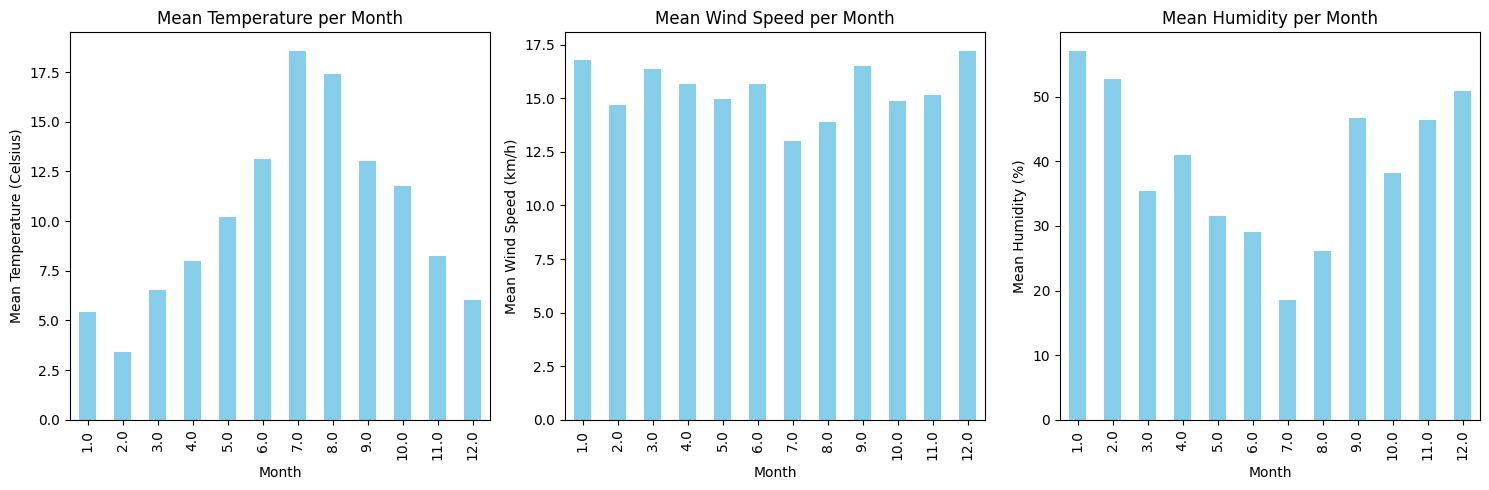

In [4]:
# Group by month and calculate mean temperature
mean_temp_per_month = INT_data.groupby('month')['localairtemperature'].mean()
mean_wind_per_month = INT_data.groupby('month')['localwindspeed'].mean()
mean_humi_per_month = INT_data.groupby('month')['localhumidity'].mean()

fig, ax = plt.subplots(1,3,figsize=(15,5))
ax = ax.ravel()

# Plotting the mean temperature per month
mean_temp_per_month.plot(kind='bar', color='skyblue', ax=ax[0])
mean_wind_per_month.plot(kind='bar', color='skyblue', ax=ax[1])
mean_humi_per_month.plot(kind='bar', color='skyblue', ax=ax[2])

ax[0].set_title('Mean Temperature per Month'); ax[1].set_title('Mean Wind Speed per Month'); ax[2].set_title('Mean Humidity per Month')
ax[0].set_xlabel('Month'); ax[1].set_xlabel('Month'); ax[2].set_xlabel('Month')
ax[0].set_ylabel('Mean Temperature (Celsius)'); ax[1].set_ylabel('Mean Wind Speed (km/h)'); ax[2].set_ylabel('Mean Humidity (%)')
#plt.xticks(rotation=45, ax=ax[0])  # Rotate x-axis labels for better readability
#ax[0].set_grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Mean temperature, humidity and wind speed by year

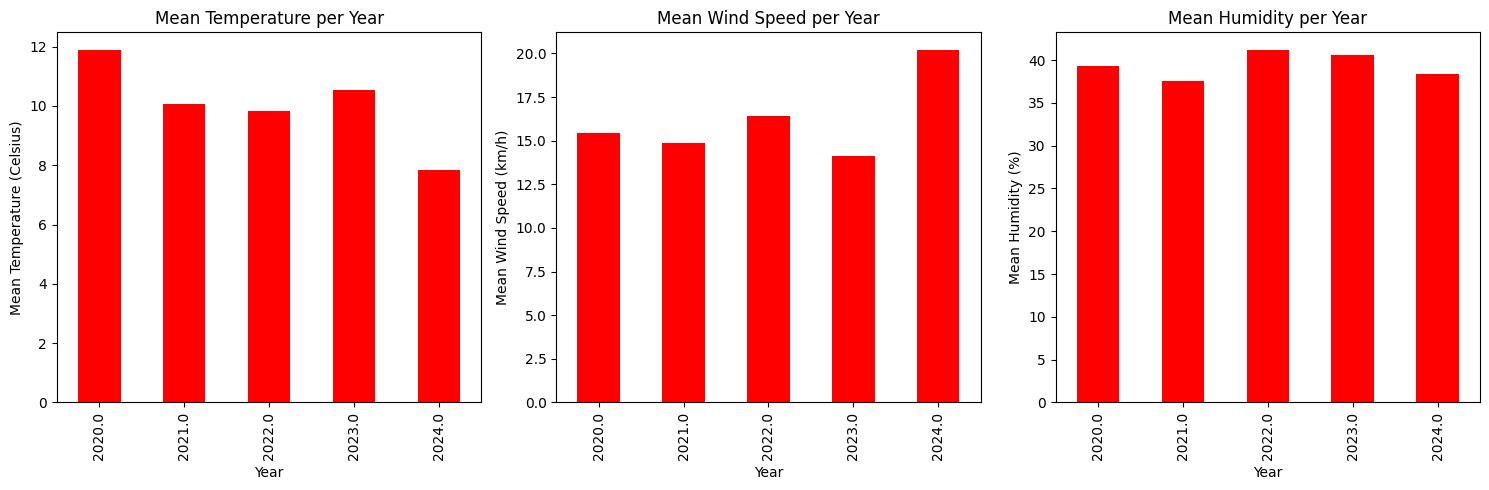

In [5]:
# Group by month and calculate mean temperature
mean_temp_per_year = INT_data.groupby('year')['localairtemperature'].mean()
mean_wind_per_year = INT_data.groupby('year')['localwindspeed'].mean()
mean_humi_per_year = INT_data.groupby('year')['localhumidity'].mean()

fig, ax = plt.subplots(1,3,figsize=(15,5))
ax = ax.ravel()

# Plotting the mean temperature per month
mean_temp_per_year.plot(kind='bar', color='red', ax=ax[0])
mean_wind_per_year.plot(kind='bar', color='red', ax=ax[1])
mean_humi_per_year.plot(kind='bar', color='red', ax=ax[2])

ax[0].set_title('Mean Temperature per Year'); ax[1].set_title('Mean Wind Speed per Year'); ax[2].set_title('Mean Humidity per Year')
ax[0].set_xlabel('Year'); ax[1].set_xlabel('Year'); ax[2].set_xlabel('Year')
ax[0].set_ylabel('Mean Temperature (Celsius)'); ax[1].set_ylabel('Mean Wind Speed (km/h)'); ax[2].set_ylabel('Mean Humidity (%)')
#plt.xticks(rotation=45, ax=ax[0])  # Rotate x-axis labels for better readability
#ax[0].set_grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## __Seeing__

In [11]:
seeing = pd.read_csv('../data/seeing_data.csv')
seeing.head()

,Date,Time,Seeing
0,2020-01-01,00:00:32,1.5096
1,2020-01-01,00:01:08,1.5786
2,2020-01-01,00:01:44,1.2777
3,2020-01-01,00:02:20,1.2360
4,2020-01-01,00:02:55,1.3859


In [12]:
# Converting to datetime
seeing['Date'] = pd.to_datetime(seeing['Date'])
seeing['Time'] = pd.to_datetime(seeing['Time'])

# Extract year
seeing['year'] = seeing['Date'].dt.year

# Extract month
seeing['month'] = seeing['Date'].dt.month

# Extract day
seeing['day'] = seeing['Date'].dt.day

# Extract hour
seeing['hour'] = seeing['Time'].dt.hour

# Extract minute
seeing['minute'] = seeing['Time'].dt.minute


# Drop the 'sampletime' column
seeing.drop(columns=['Date', 'Time'], inplace=True)

seeing.head()

/tmp/ipykernel_40891/3229254856.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  seeing['Time'] = pd.to_datetime(seeing['Time'])


,Seeing,year,month,day,hour,minute
0,1.5096,2020,1,1,0,0
1,1.5786,2020,1,1,0,1
2,1.2777,2020,1,1,0,1
3,1.2360,2020,1,1,0,2
4,1.3859,2020,1,1,0,2


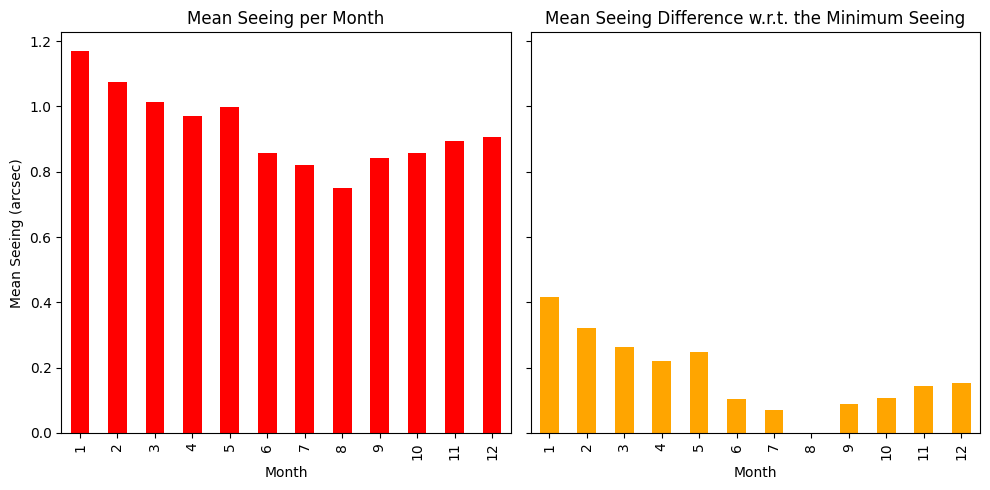

In [13]:
# Group by month and calculate mean temperature
mean_seeing_per_month = seeing.groupby('month')['Seeing'].mean()

fig, ax = plt.subplots(1,2,figsize=(10,5), sharey=True)
ax = ax.ravel()

# Plotting the mean temperature per month
mean_seeing_per_month.plot(kind='bar', color='red', ax=ax[0])
(mean_seeing_per_month - min(mean_seeing_per_month)).plot(kind='bar', color='orange', ax=ax[1])

ax[0].set_title('Mean Seeing per Month'); ax[1].set_title('Mean Seeing Difference w.r.t. the Minimum Seeing');
ax[0].set_xlabel('Month'); ax[1].set_xlabel('Month');
ax[0].set_ylabel('Mean Seeing (arcsec)'); #ax[1].set_ylabel('Mean Seeing (km/h)'); ax[2].set_ylabel('Mean Humidity (%)')
#plt.xticks(rotation=45, ax=ax[0])  # Rotate x-axis labels for better readability
#ax[0].set_grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [14]:
# Calculate the difference in seeing values per minute
seeing['seeing_diff'] = seeing['Seeing'].diff()

# Print the DataFrame to inspect the results
print(seeing)

# Calculate the mean absolute difference per minute
mean_diff_per_minute = seeing['seeing_diff'].abs().mean()

print("Mean absolute difference per minute:", mean_diff_per_minute)

        Seeing  year  month  day  hour  minute  seeing_diff
0       1.5096  2020      1    1     0       0          NaN
1       1.5786  2020      1    1     0       1       0.0690
2       1.2777  2020      1    1     0       1      -0.3009
3       1.2360  2020      1    1     0       2      -0.0417
4       1.3859  2020      1    1     0       2       0.1499
...        ...   ...    ...  ...   ...     ...          ...
600839  1.2730  2024      2   20    23      57       0.0101
600840  0.9883  2024      2   20    23      57      -0.2847
600841  0.8413  2024      2   20    23      58      -0.1470
600842  0.8875  2024      2   20    23      59       0.0462
600843  0.9787  2024      2   20    23      59       0.0912

[600844 rows x 7 columns]
Mean absolute difference per minute: 0.1255427455327421


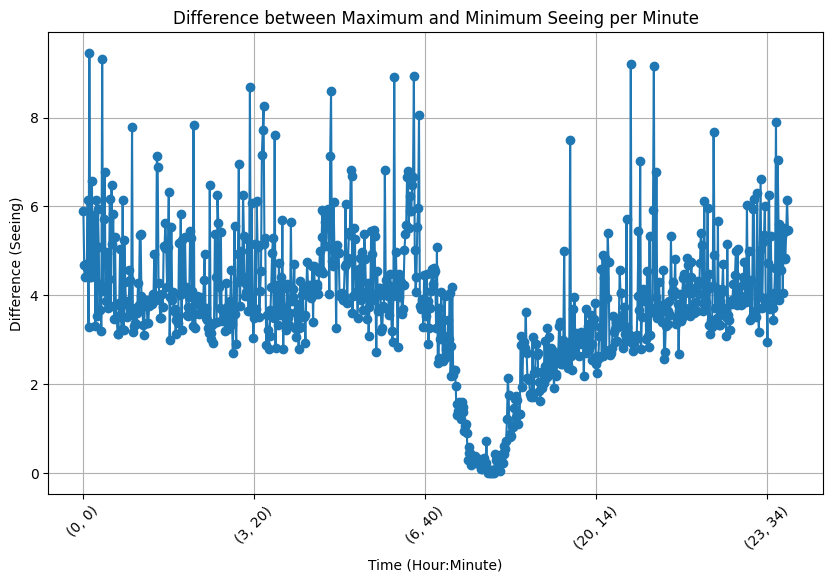

In [16]:
# Group by hour and minute and calculate the difference between max and min seeing values
minute_seeing_difference = seeing.groupby([seeing['hour'], seeing['minute']])['Seeing'].apply(lambda x: x.max() - x.min() )

# Plot the variation per minute
plt.figure(figsize=(10, 6))
minute_seeing_difference.plot(marker='o', linestyle='-')
plt.title('Difference between Maximum and Minimum Seeing per Minute')
plt.xlabel('Time (Hour:Minute)')
plt.ylabel('Difference (Seeing)')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

### Combined data

In [15]:
# First, we create the Datetime column and resample the seeing for each 10 minutes
# Converting the Datetime column into datetime format
seeing['Datetime'] = pd.to_datetime(seeing[['year', 'month', 'day', 'hour', 'minute']])

# Converting the Datetime column into datetime format
seeing.Datetime = pd.to_datetime(seeing['Datetime'])

# Deleting the old columns
seeing.drop(['year','month','day','hour','minute'], axis=1, inplace=True)

# Displaying how the data looks like
seeing.head()

,Seeing,seeing_diff,Datetime
0,1.5096,NaN,2020-01-01 00:00:00
1,1.5786,0.0690,2020-01-01 00:01:00
2,1.2777,-0.3009,2020-01-01 00:01:00
3,1.2360,-0.0417,2020-01-01 00:02:00
4,1.3859,0.1499,2020-01-01 00:02:00


In [16]:
# Now we resample the DataFrame each 10 minutes (we take the columns Datetime for the resampling)
seeing_resample = seeing.resample('10T', on='Datetime').mean()

# Last, we recover the columns year, month, day, hour, minute, second from the Datetime column and we recover a regular index column
seeing_resample.reset_index(inplace = True);
seeing_resample.head()

# recovering each time column
seeing_resample['year']   = seeing_resample.Datetime.dt.year
seeing_resample['month']  = seeing_resample.Datetime.dt.month
seeing_resample['day']    = seeing_resample.Datetime.dt.day
seeing_resample['hour']   = seeing_resample.Datetime.dt.hour
seeing_resample['minute'] = seeing_resample.Datetime.dt.minute

# Deleting the Datetime column
seeing_resample.drop('Datetime', axis=1, inplace=True)

print(seeing_resample)

          Seeing  seeing_diff  year  month  day  hour  minute
0       1.377350    -0.001000  2020      1    1     0       0
1       1.547224     0.011547  2020      1    1     0      10
2       1.632365    -0.016829  2020      1    1     0      20
3       1.502673     0.007309  2020      1    1     0      30
4       1.406213    -0.014793  2020      1    1     0      40
...          ...          ...   ...    ...  ...   ...     ...
217723  1.070144    -0.050744  2024      2   20    23      10
217724  0.824625    -0.068075  2024      2   20    23      20
217725  1.038912     0.021606  2024      2   20    23      30
217726  1.038929    -0.010671  2024      2   20    23      40
217727  1.149365     0.002729  2024      2   20    23      50

[217728 rows x 7 columns]


/tmp/ipykernel_40891/1094474323.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  seeing_resample = seeing.resample('10T', on='Datetime').mean()


In [17]:
# Right join on seeing
combined = pd.merge(data_resample, seeing_resample, on=['year', 'month', 'day', 'hour', 'minute'], how='right')

# Dropping NaNs
combined = combined.dropna()

# Deleting the seeing_diff variable
combined.drop('seeing_diff', axis=1, inplace=True)

In [18]:
# Convert the seeing into logharitmic scale to improve the fitting
combined['Seeing'] = np.log(combined['Seeing'])

# Check for inf, nans or null values for this new target variable
combined = combined[~(combined['Seeing'] == -np.inf)]

/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


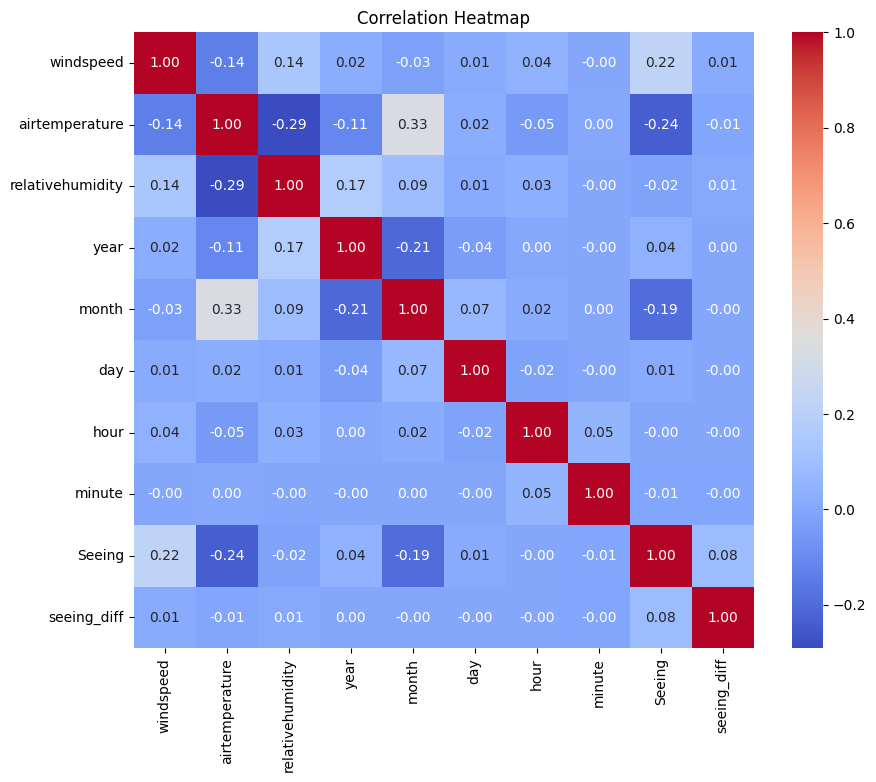

In [81]:
# Assuming combined is your DataFrame
correlation_matrix = combined.corr()

# Plotting the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Correlation Heatmap')
plt.show()

In [111]:
# Let's plot the most correlated variables with the seeing
abs(combined.corr())['Seeing'].drop('Seeing').sort_values(ascending=False)

airtemperature      0.222056
month               0.193204
windspeed           0.187638
year                0.047643
hour                0.015457
minute              0.007365
relativehumidity    0.004882
day                 0.004663
Name: Seeing, dtype: float64

In [112]:
# As minute, hour and day have very low correlation with the seeing, we can delete them. We cannot quit year as
# it has strong correlation with month, and month correlates with seeing
#combined = combined.drop(columns=['minute', 'hour', 'day', 'year'])

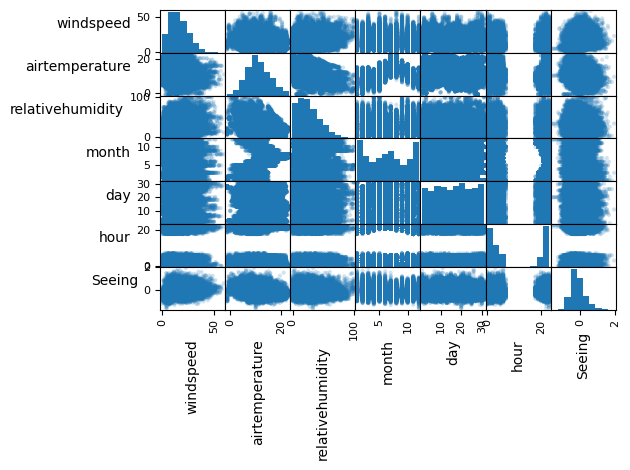

In [97]:
axes = pd.plotting.scatter_matrix(combined.drop(columns=['year','minute']), alpha=0.2)
# need to rotate axis labels so we can read them
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')

plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0, hspace=0)
plt.show()

Generating an output csv with the current data

In [152]:
combined.to_csv('../data/cleaned_WHT_seeing_data.csv')

In [21]:
temp_cols = ['year', 'month', 'day', 'hour', 'minute']
combined['timestamp'] = pd.to_datetime(combined[temp_cols])

We only have seeing data during nights, so it is mandatory to:
1. Sorted the DataFrame by the date.
2. Combine all data from one night to the next one.
3. Delete data during daytime (this could be furhter skipped for different ML models).

In [ ]:
# Let's order the dataset 'combined' by the timestamp column and reset the index
combined = combined.sort_values('timestamp').reset_index(drop=True)
combined.head()

# Define nights as shifts: 17:00 (D) → 08:00 (D+1)
ts = combined['timestamp']
hours = ts.dt.hour

# Nighttime mask: only 17:00–23:50 and 00:00–07:50
is_night = (hours >= 17) | (hours < 8)

# Base date at midnight of the calendar day
night_date = ts.dt.normalize()

# For times before 08:00, assign them to the previous calendar day
night_date[hours < 8] = night_date[hours < 8] - pd.Timedelta(days=1)

# Drop daytime rows and keep only real nights
night_date[~is_night] = pd.NaT

# Optionally, keep only nighttime rows going forward
combined = combined[is_night].copy()

# Last, we do not need the timestamp column anymore, so we can drop it
combined.drop('timestamp', axis=1, inplace=True)

combined.head()

/tmp/ipykernel_40891/3313422474.py:16: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  night_date[hours < 8] = night_date[hours < 8] - pd.Timedelta(days=1)
/tmp/ipykernel_40891/3313422474.py:16: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  night_date[hours < 8] = night_date[hours < 8] - pd.Timedelta(days=1)
/tmp/ipykernel_40891/3313422474.py:19: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  night_date[~is_night] = pd.NaT
/tmp/ipykernel_40891/3313422474.py:19: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  night_date[~is_night] = pd.NaT


,windspeed,airtemperature,relativehumidity,year,month,day,hour,minute,Seeing,timestamp,night_id
0,12.919399,7.173338,35.522751,2020,1,31,19,10,-0.238520,2020-01-31 19:10:00,2020-01-31
1,13.455912,7.151790,36.587791,2020,1,31,19,20,0.030923,2020-01-31 19:20:00,2020-01-31
2,16.018960,7.253796,34.251087,2020,1,31,19,30,0.261599,2020-01-31 19:30:00,2020-01-31
3,15.579474,7.402426,33.061798,2020,1,31,19,40,0.308435,2020-01-31 19:40:00,2020-01-31
4,16.778657,7.355480,33.812691,2020,1,31,19,50,0.373899,2020-01-31 19:50:00,2020-01-31


## __Preliminar machine learning models__

In [29]:
from sklearn import model_selection, preprocessing
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate, train_test_split
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor
import xgboost as xgb

In [64]:
target = combined.Seeing
data   = combined.drop(columns='Seeing')

In [65]:
# Creating a function to convert seconds, minutes, hours, days, and months into sine and cosine functions to preserve
# their ccyclic nature
def convert_temp_feat(data, feature, period):
    if feature == 'day':
        dt = pd.to_datetime(dict(
            year=data["year"],
            month=data["month"],
            day=data["day"],
            hour=data["hour"],
            minute=data["minute"],
            # second=data["second"],  # uncomment if you have it
        ), errors="coerce")

        # ---- Annual seasonality (handles varying month lengths + leap years) ----
        doy = dt.dt.dayofyear
        year_len = 365.2425  # average length; good practical approximation
        data["doy_sin"] = np.sin(2 * np.pi * (doy / year_len))
        data["doy_cos"] = np.cos(2 * np.pi * (doy / year_len))
        data.drop('day', axis=1, inplace=True)
    else:
        data[feature+'_sin'] = np.sin(2 * np.pi * data[feature] / period)
        data[feature+'_cos'] = np.cos(2 * np.pi * data[feature] / period)
        data.drop(feature, axis=1, inplace=True)
    return data

In [66]:
data = convert_temp_feat(data, 'day', _)
data = convert_temp_feat(data, 'minute', 60)
data = convert_temp_feat(data, 'hour', 24)
data = convert_temp_feat(data, 'month', 12)

In [67]:
# Identificar las columnas de tipo bool
bool_cols = data.select_dtypes(include=['bool']).columns

# Convertir las columnas de tipo bool a int32
data[bool_cols] = data[bool_cols].astype('int32')

In [68]:
# Let's normalise numerical columns to get them in the same range with mean 0 and std 1
cols_to_scale = data.select_dtypes(include=[np.number]).columns

# Calling the normaliser
# Identify the continuous numerical columns to scale
# (These are usually of float type - already selected as cols_to_scale above)
scaler = preprocessing.StandardScaler()

# Rescaling the columns
data[cols_to_scale] = scaler.fit_transform(data[cols_to_scale])

In [ ]:
# First, web split the data into training and testing sets. We will use 80% of the data for training and 20% for testing.
# We also need to stratify the data by month to ensure that we have a representative distribution of months in both sets, as month is an important variable for the seeing
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state= 101)

# Then, we need to split the training set into a training and validation set. We will use 80% of the training set for training and 20% for validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state= 101)

### Random Forest Regressor

In [57]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=300,       
    max_depth=None,           # or even 10–15 if performance holds
    min_samples_leaf=1,     # prevents extremely deep/sparse leaves
    max_features=0.5,    # or 0.3–0.5 to reduce split cost
    max_samples=0.7,        # use 70% of samples per tree (if sklearn >= 0.22)
    bootstrap=True,
    n_jobs=4,               # lower parallelism to reduce RAM peaks
    random_state=0
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)

In [59]:
# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_val, y_pred)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_val, y_pred)

# Calculate R-squared (R2)
r2 = r2_score(y_val, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R-squared (R2):", r2)

Mean Absolute Error (MAE): 0.14480025112448863
Mean Squared Error (MSE): 0.03912121354358124
R-squared (R2): 0.746582858128561


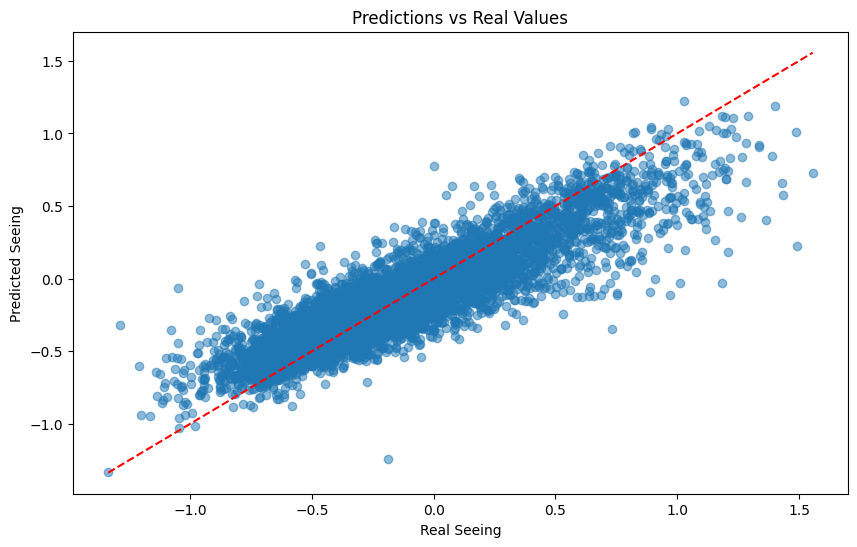

In [38]:
# Let's plot the predictions vs the real values with a line of identity
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Real Seeing')
plt.ylabel('Predicted Seeing')
plt.title('Predictions vs Real Values')
plt.show()

In [63]:
# Checking if the model underfits or overfits by comparing the performance on the training and testing sets
y_pred_train = rf.predict(X_train)
rmse_train = root_mean_squared_error(y_train, y_pred_train)
y_pred_test = rf.predict(X_test)
rmse_test  = root_mean_squared_error(y_test, y_pred_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test, y_pred_test)

print('Difference in RMSE:', rmse_train-rmse_test)
print('Difference in R2:', r2_train-r2_test)

Difference in RMSE: -0.09937203167877397
Difference in R2: 0.18825331966559666


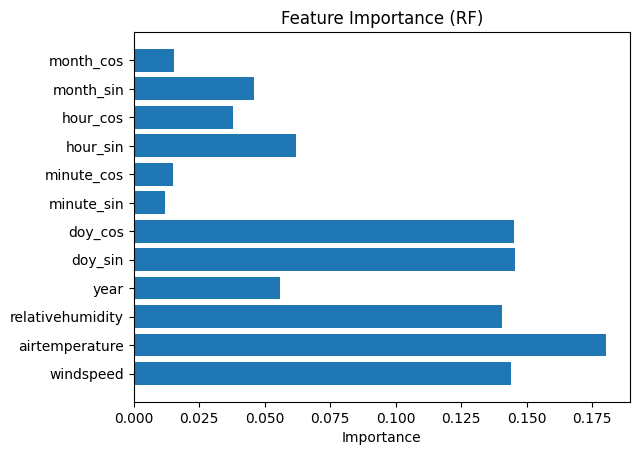

In [48]:
# Let's plot the feature importance from the RF
feature_importance = rf.feature_importances_

plt.barh(X_train.columns, feature_importance)
plt.title("Feature Importance (RF)")
plt.xlabel("Importance")
plt.show()

### HistGradientBoostingRegressor

In [49]:
# Let's build a HistGradientBoostingRegressor
hgb = HistGradientBoostingRegressor(
    loss="squared_error",   
    learning_rate=0.05,     # smaller lr, more trees
    max_iter=300,           # boosting stages (like n_estimators)
    max_depth=None,         # or 6–10 if overfitting
    max_leaf_nodes=30,      # tree size; 31 is a solid default
    min_samples_leaf=20,    # regularization; 10–50 is a good search range
    max_bins=255,           # histogram bins; can reduce to ~127 to save memory
    l2_regularization=0.01, # mild regularization
    early_stopping=False,    # uses validation split internally
    validation_fraction=0.2,
    random_state=0
)

hgb.fit(X_train, y_train)

y_pred = hgb.predict(X_test)

# Calculate Mean Absolute Error (MAE)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('Mean Squared Error (MSE):', mse)
print('R-squared (R2):', r2)

Mean Squared Error (MSE): 0.06753137110549896
R-squared (R2): 0.5705543638606922


### Dense Neural Network

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Design the neural network model with 
model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(1)  # Output layer with single neuron for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Re-scaling also the target variable for performance imrpovements
# Crear y ajustar el MinMaxScaler para la variable objetivo
scaler_y = preprocessing.MinMaxScaler()

# Training set
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# Train the model
history = model.fit(X_train, y_train_scaled, epochs=50, batch_size=32, validation_split=0.2)

# Evaluate the model on test data
loss, mae = model.evaluate(X_test, y_test_scaled)
print("Mean Squared Error (MSE):", loss)
print("Mean Absolute Error (MAE):", mae)

2026-03-17 19:29:38.695308: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-17 19:29:39.078345: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-17 19:29:39.078456: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-17 19:29:39.203918: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-17 19:29:39.377628: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-17 19:29:39.379805: I tensorflow/core/platform/cpu_feature_guard.cc:1

Epoch 1/50


2026-03-17 19:29:41.691879: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


610/610 [==============================] - 2s 2ms/step - loss: 0.0143 - mae: 0.0912 - val_loss: 0.0128 - val_mae: 0.0897
Epoch 2/50
610/610 [==============================] - 1s 2ms/step - loss: 0.0119 - mae: 0.0839 - val_loss: 0.0116 - val_mae: 0.0829
Epoch 3/50
610/610 [==============================] - 1s 1ms/step - loss: 0.0113 - mae: 0.0815 - val_loss: 0.0112 - val_mae: 0.0814
Epoch 4/50
610/610 [==============================] - 1s 1ms/step - loss: 0.0108 - mae: 0.0798 - val_loss: 0.0106 - val_mae: 0.0795
Epoch 5/50
610/610 [==============================] - 1s 2ms/step - loss: 0.0103 - mae: 0.0776 - val_loss: 0.0107 - val_mae: 0.0804
Epoch 6/50
610/610 [==============================] - 1s 1ms/step - loss: 0.0099 - mae: 0.0758 - val_loss: 0.0100 - val_mae: 0.0759
Epoch 7/50
610/610 [==============================] - 1s 2ms/step - loss: 0.0096 - mae: 0.0747 - val_loss: 0.0103 - val_mae: 0.0789
Epoch 8/50
610/610 [==============================] - 1s 2ms/step - loss: 0.0091 - mae:

  1/239 [..............................] - ETA: 7s

239/239 [==============================] - 0s 500us/step
R-squared (R2): 0.6439643214215127


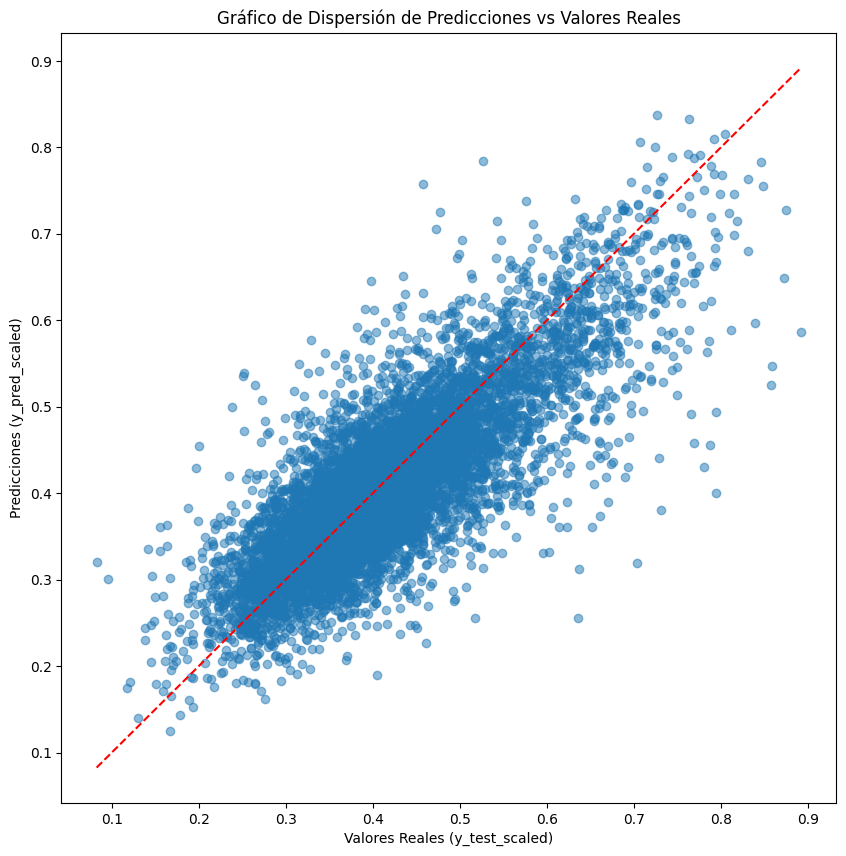

/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/s

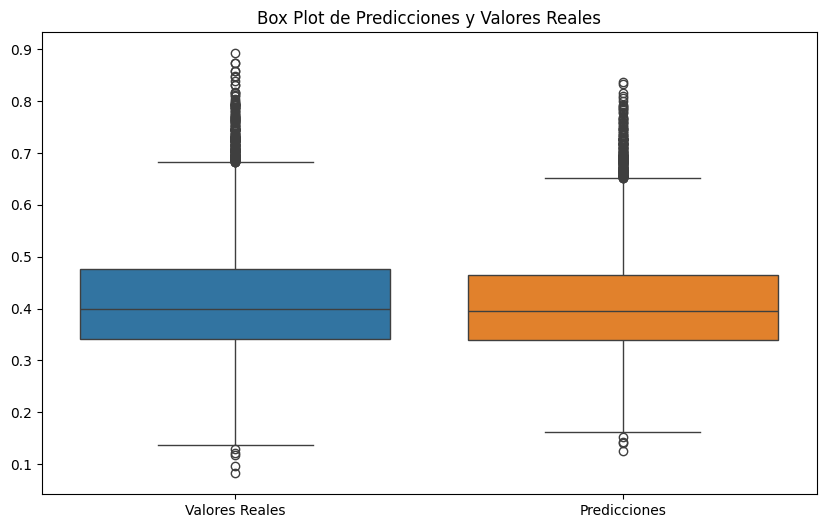

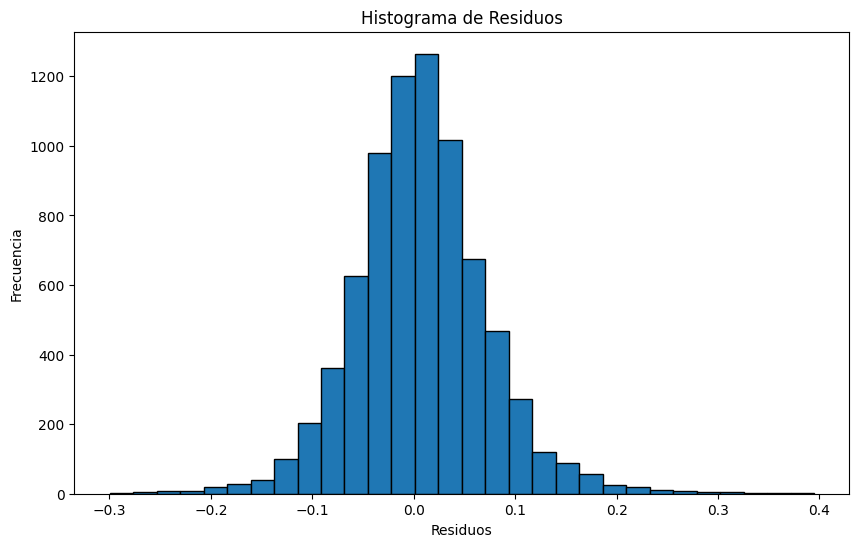

In [119]:
# Applying the DNN over the testing set
y_pred = model.predict(X_test)

# Calculate R-squared (R2)
r2 = r2_score(y_test_scaled, y_pred)
print("R-squared (R2):", r2)

# Gráfico de dispersión
plt.figure(figsize=(10,10))
plt.scatter(y_test_scaled, y_pred, alpha=0.5)
plt.plot([min(y_test_scaled), max(y_test_scaled)], [min(y_test_scaled), max(y_test_scaled)], color='red', linestyle='--')
plt.xlabel('Valores Reales (y_test_scaled)')
plt.ylabel('Predicciones (y_pred_scaled)')
plt.title('Gráfico de Dispersión de Predicciones vs Valores Reales')
plt.show()

# Boxplot de datos predecidos vs datos reales
import seaborn as sns

# Crear un DataFrame para las comparaciones
df_comparacion = pd.DataFrame({
    'Valores Reales': y_test_scaled.flatten(),
    'Predicciones': y_pred.flatten()
})

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_comparacion)
plt.title('Box Plot de Predicciones y Valores Reales')
plt.show()

residuos = y_test_scaled - y_pred

# Histograma de residuos
plt.figure(figsize=(10, 6))
plt.hist(residuos, bins=30, edgecolor='k')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.title('Histograma de Residuos')
plt.show()